Start with a small real dataset (~500 MB) → learn the pipeline → then scale to OpenNeuro ds005237 or HCP later.

This avoids waiting hours for downloads while you’re still learning.

We’ll use a standard Nilearn tutorial dataset that many neuroimaging courses start with.

First time it runs it will download ~400–500 MB.

After that it loads instantly.

You will see paths like:

~/nilearn_data/development_fmri/...

In [1]:
# imports
import numpy as np
from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker

# atlas
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=200, yeo_networks=7)

# dataset
development_dataset = datasets.fetch_development_fmri(n_subjects=1)

[fetch_atlas_schaefer_2018] Dataset found in /home/john-walkey/nilearn_data/schaefer_2018
[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri
[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri/development_fmri
[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri/development_fmri


In [2]:
from nilearn import datasets

# download a small resting-state dataset
development_dataset = datasets.fetch_development_fmri(n_subjects=1)

print("Functional file:")
print(development_dataset.func[0])

print("\nConfounds file:")
print(development_dataset.confounds[0])

[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri
[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri/development_fmri
[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri/development_fmri
Functional file:
/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz

Confounds file:
/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_desc-reducedConfounds_regressors.tsv


## Now we need brain regions:

### This atlas divides the brain into 200 regions.

Some of those regions belong to:

DMN

salience network

visual network

motor network

In [3]:
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=200)

atlas_filename = atlas.maps
print(atlas_filename)

[fetch_atlas_schaefer_2018] Dataset found in /home/john-walkey/nilearn_data/schaefer_2018
/home/john-walkey/nilearn_data/schaefer_2018/Schaefer2018_200Parcels_7Networks_order_FSLMNI152_1mm.nii.gz


Above code loads the brain atlas


Extract Brain Region Time Series

In [4]:
from nilearn.maskers import NiftiLabelsMasker

masker = NiftiLabelsMasker(
    labels_img=atlas_filename,
    standardize=True,
    memory="nilearn_cache",
    verbose=1
)

time_series = masker.fit_transform(development_dataset.func[0])

print("Time series shape:", time_series.shape)

[NiftiLabelsMasker.wrapped] Loading regions from '/home/john-walkey/nilearn_data/schaefer_2018/Schaefer2018_200Parcels_7Networks_order_FSLMNI152_1mm.nii.gz'
[NiftiLabelsMasker.wrapped] Resampling regions
[NiftiLabelsMasker.wrapped] Finished fit
Time series shape: (168, 200)


/tmp/ipykernel_4187/791187366.py:10: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(development_dataset.func[0])


Compute connectivity index

In [5]:
import numpy as np

correlation_matrix = np.corrcoef(time_series.T)

print("Connectivity matrix shape:", correlation_matrix.shape)

Connectivity matrix shape: (200, 200)


Visualize the Brain Network

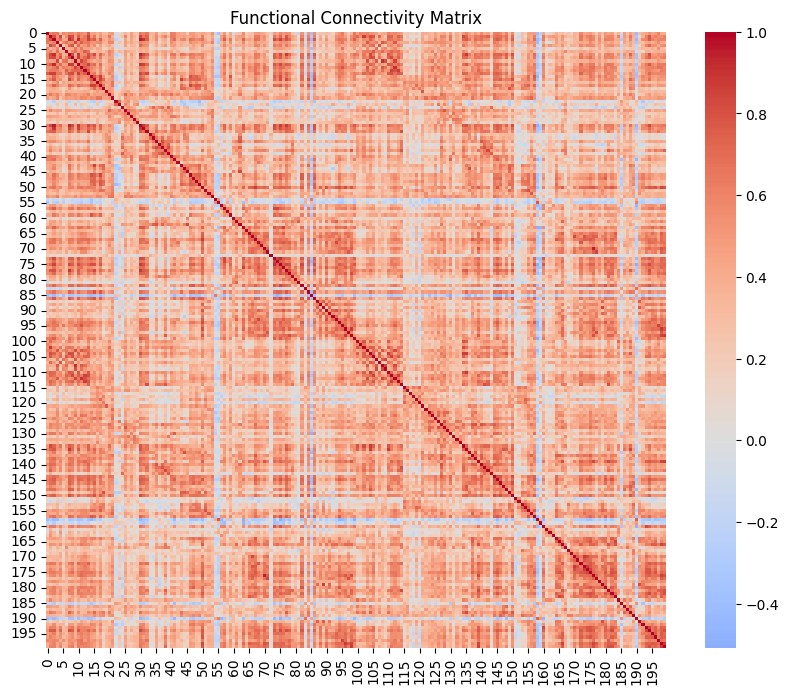

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)
plt.title("Functional Connectivity Matrix")
plt.show()

You just ran the standard pipeline used in network neuroscience:

fMRI scan
      ↓
brain atlas
      ↓
extract regional signals
      ↓
correlation matrix
      ↓
brain network

That’s the computational foundation of:

DMN research

salience network research

connectomics

psychiatric biomarker studies

## Next Step — Identify DMN Regions in the Atlas

We downloaded the Schaefer atlas (200 regions).

Each region has a label like:

7Networks_LH_Default_PFC_1
7Networks_LH_Default_PCC_1
7Networks_RH_Default_Temp_1

The keyword “Default” indicates the Default Mode Network (DMN).

In [7]:
labels = atlas.labels

# convert from bytes to text if needed
labels = [l.decode() if isinstance(l, bytes) else l for l in labels]

# find DMN regions
dmn_indices = [i for i, label in enumerate(labels) if "Default" in label]

print("Number of DMN regions:", len(dmn_indices))
print("\nExample DMN labels:")

for i in dmn_indices[:10]:
    print(i, labels[i])

Number of DMN regions: 46

Example DMN labels:
74 7Networks_LH_Default_Temp_1
75 7Networks_LH_Default_Temp_2
76 7Networks_LH_Default_Temp_3
77 7Networks_LH_Default_Temp_4
78 7Networks_LH_Default_Temp_5
79 7Networks_LH_Default_Par_1
80 7Networks_LH_Default_Par_2
81 7Networks_LH_Default_Par_3
82 7Networks_LH_Default_Par_4
83 7Networks_LH_Default_PFC_1


What you should see

Something like:

Number of DMN regions: 30

7Networks_LH_Default_PFC_1
7Networks_LH_Default_PCC_1
7Networks_RH_Default_Temp_1
...

## Next Step — Identify Insula Regions

In [8]:
insula_indices = [i for i, label in enumerate(labels) if "SalVentAttn" in label]

print("Possible insula/salience regions:", len(insula_indices))

for i in insula_indices[:10]:
    print(i, labels[i])

Possible insula/salience regions: 22
44 7Networks_LH_SalVentAttn_ParOper_1
45 7Networks_LH_SalVentAttn_ParOper_2
46 7Networks_LH_SalVentAttn_ParOper_3
47 7Networks_LH_SalVentAttn_FrOperIns_1
48 7Networks_LH_SalVentAttn_FrOperIns_2
49 7Networks_LH_SalVentAttn_FrOperIns_3
50 7Networks_LH_SalVentAttn_FrOperIns_4
51 7Networks_LH_SalVentAttn_PFCl_1
52 7Networks_LH_SalVentAttn_Med_1
53 7Networks_LH_SalVentAttn_Med_2


## Next Step — Compute Insula–DMN Connectivity


In [9]:
insula_dmn_connections = []

for insula in insula_indices:
    for dmn in dmn_indices:
        if insula < correlation_matrix.shape[0] and dmn < correlation_matrix.shape[1]:
            insula_dmn_connections.append(correlation_matrix[insula, dmn])

import numpy as np

mean_connectivity = np.mean(insula_dmn_connections)

print("Average insula–DMN connectivity:", mean_connectivity)

Average insula–DMN connectivity: 0.2638438524983146


## What you just computed

This value represents:

insula ↔ DMN functional connectivity

That is exactly the variable your research question needs.

Later you will test:

Trait Anxiety → Insula–DMN connectivity
Why this is exciting

You have already implemented the core of your PhD analysis pipeline:

fMRI data
     ↓
brain atlas
     ↓
time series extraction
     ↓
connectivity matrix
     ↓
network connectivity metric

Most neuroscience papers using connectomics are just variations of this pipeline.

Next (very important)

The next step I’d recommend is something that will make this much easier to interpret visually:

We will plot the DMN regions directly on the brain.

When you see this, the whole concept of network neuroscience becomes intuitive.

It’s also very cool visually. 🧠

In [10]:
labels = atlas.labels
labels = [l.decode() if isinstance(l, bytes) else l for l in labels]

dmn_indices = [i for i, label in enumerate(labels) if "Default" in label]

print("Number of DMN regions:", len(dmn_indices))
print("First few DMN labels:")
for i in dmn_indices[:10]:
    print(i, labels[i])

Number of DMN regions: 46
First few DMN labels:
74 7Networks_LH_Default_Temp_1
75 7Networks_LH_Default_Temp_2
76 7Networks_LH_Default_Temp_3
77 7Networks_LH_Default_Temp_4
78 7Networks_LH_Default_Temp_5
79 7Networks_LH_Default_Par_1
80 7Networks_LH_Default_Par_2
81 7Networks_LH_Default_Par_3
82 7Networks_LH_Default_Par_4
83 7Networks_LH_Default_PFC_1


Step 2 — Create a DMN-only atlas image

In [11]:
import numpy as np
import nibabel as nib

# Load atlas image data
atlas_img = nib.load(atlas.maps)
atlas_data = atlas_img.get_fdata()

# Create empty image
dmn_data = np.zeros_like(atlas_data)

# Keep only DMN parcels
for idx in dmn_indices:
    parcel_value = idx + 1  # Schaefer atlas parcel numbering starts at 1
    dmn_data[atlas_data == parcel_value] = parcel_value

# Make new NIfTI image
dmn_img = nib.Nifti1Image(dmn_data, atlas_img.affine, atlas_img.header)

print("DMN image created.")

DMN image created.


Step 3 — Plot the DMN on the brain

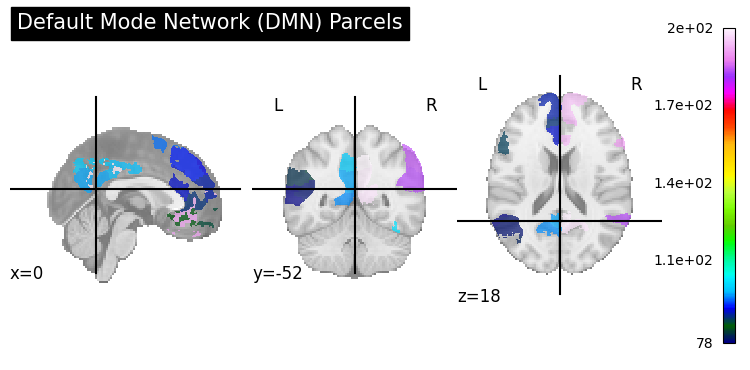

In [12]:
from nilearn import plotting

plotting.plot_roi(
    dmn_img,
    title="Default Mode Network (DMN) Parcels",
    display_mode="ortho",
    cut_coords=(0, -52, 18),
    colorbar=True
)

plotting.show()

You should now see the DMN parcels plotted on the brain.

Typical DMN areas include:

medial prefrontal cortex

posterior cingulate / precuneus

angular gyrus

temporal/parietal association areas

Step 4 — Try a glass brain view

This often looks even nicer.

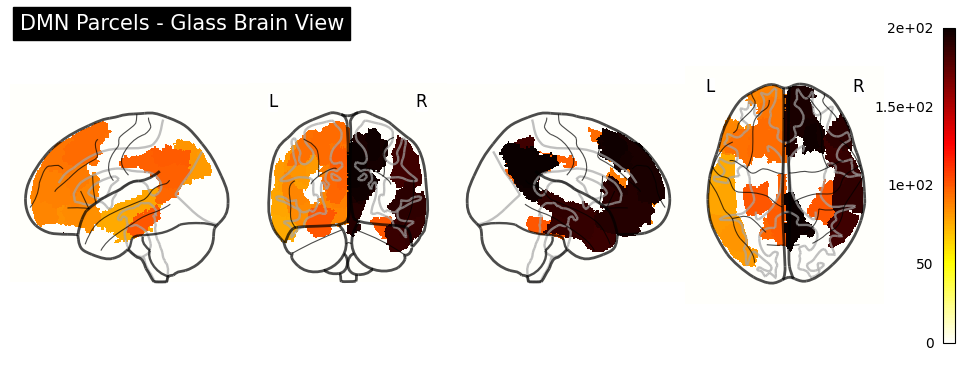

In [13]:
plotting.plot_glass_brain(
    dmn_img,
    title="DMN Parcels - Glass Brain View",
    display_mode="lyrz",
    colorbar=True
)

plotting.show()

Step 5 — Print the DMN labels beside the figure

In [14]:
print("DMN parcel labels:")
for i in dmn_indices:
    print(i + 1, labels[i])

DMN parcel labels:
75 7Networks_LH_Default_Temp_1
76 7Networks_LH_Default_Temp_2
77 7Networks_LH_Default_Temp_3
78 7Networks_LH_Default_Temp_4
79 7Networks_LH_Default_Temp_5
80 7Networks_LH_Default_Par_1
81 7Networks_LH_Default_Par_2
82 7Networks_LH_Default_Par_3
83 7Networks_LH_Default_Par_4
84 7Networks_LH_Default_PFC_1
85 7Networks_LH_Default_PFC_2
86 7Networks_LH_Default_PFC_3
87 7Networks_LH_Default_PFC_4
88 7Networks_LH_Default_PFC_5
89 7Networks_LH_Default_PFC_6
90 7Networks_LH_Default_PFC_7
91 7Networks_LH_Default_PFC_8
92 7Networks_LH_Default_PFC_9
93 7Networks_LH_Default_PFC_10
94 7Networks_LH_Default_PFC_11
95 7Networks_LH_Default_PFC_12
96 7Networks_LH_Default_PFC_13
97 7Networks_LH_Default_pCunPCC_1
98 7Networks_LH_Default_pCunPCC_2
99 7Networks_LH_Default_pCunPCC_3
100 7Networks_LH_Default_pCunPCC_4
101 7Networks_LH_Default_PHC_1
183 7Networks_RH_Default_Par_1
184 7Networks_RH_Default_Par_2
185 7Networks_RH_Default_Par_3
186 7Networks_RH_Default_Temp_1
187 7Networks_RH_De

Note the + 1 there:

Python list indices start at 0

atlas parcel values usually start at 1

What this means

You are now seeing the Default Mode Network as a set of parcels, not just as an abstract concept.

That matters because your project is really about this kind of relationship:

insula parcels  <-->  DMN parcels

So once you can visualize the DMN, the next logical step is to do the same for:

salience / ventral attention parcels

possible insula-related parcels

then compare their connectivity

Small caution

In the Schaefer atlas, the “insula” is not always labeled explicitly as “insula.” Many relevant parcels fall under:

"SalVentAttn"

So Schaefer is very good for network analysis, but for a cleaner anatomical insula ROI, we may also bring in the Harvard-Oxford atlas next.

That combination is often ideal:

Schaefer for DMN/network parcels

Harvard-Oxford for anatomical insula

After you run this

The next best step is to plot the salience / ventral attention parcels the same way, so you can visually compare them against the DMN.

Next exciting step (this makes it much clearer)

Instead of averaging everything, we will visualize the insula–DMN connections directly as a brain network graph.

It looks like this conceptually:

Insula nodes  ───── connections ───── DMN nodes

When you see this plotted on the brain, the whole connectomics idea becomes intuitive.

If you want, I can show you the 10-line Nilearn function that plots brain connectivity networks (it’s one of the coolest tools in neuroimaging).

Step 1 — Install one extra tool (if needed)
pip install networkx

Step 2 — Get brain region coordinates

We need coordinates for each parcel in the atlas.

In [15]:
from nilearn import datasets

atlas = datasets.fetch_atlas_schaefer_2018(n_rois=200, yeo_networks=7)

print("Atlas loaded")

[fetch_atlas_schaefer_2018] Dataset found in /home/john-walkey/nilearn_data/schaefer_2018
Atlas loaded


In [16]:
from nilearn.plotting import find_parcellation_cut_coords

coords = find_parcellation_cut_coords(atlas.maps)

print("Number of region coordinates:", len(coords))

Number of region coordinates: 200


Quick explanation (important concept)

The atlas object contains several things:

atlas
 ├── maps    → brain image with parcel labels
 ├── labels  → names of each parcel

So when we run:

atlas.maps

we are passing the parcel image to Nilearn so it can compute coordinates for each region.

Small notebook tip (very important habit)

In Jupyter notebooks, it is common practice to create a setup cell at the very top that loads everything.

Example first cell:

import numpy as np
import pandas as pd
from nilearn import datasets
from nilearn import plotting

atlas = datasets.fetch_atlas_schaefer_2018(n_rois=200, yeo_networks=7)

Then all later cells can rely on that.

What happens next

Once coords works, we can move on to the really cool step:

Plotting the insula–DMN connectivity network on the brain.

That visualization is where network neuroscience becomes intuitive.

When you run the coordinate code successfully, tell me and I will give you the next cell (only about 8 lines) that produces the brain network graph.

Cell A — Make sure atlas, labels, and your indices exist

Run this first (even if you already did; it prevents the “not defined” errors):

In [17]:
from nilearn import datasets

# Atlas (200 parcels, 7-network labeling)
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=200, yeo_networks=7)

# Labels
labels = atlas.labels
labels = [l.decode() if isinstance(l, bytes) else l for l in labels]

# Indices for DMN and Salience/Ventral Attention (proxy for insula-ish parcels)
dmn_indices = [i for i, lab in enumerate(labels) if "Default" in lab]
insula_indices = [i for i, lab in enumerate(labels) if ("SalVentAttn" in lab) or ("VentAttn" in lab) or ("Salience" in lab)]

print("DMN parcels:", len(dmn_indices), " | Sal/VentAttn parcels:", len(insula_indices))
print("Max index check:", max(dmn_indices + insula_indices), "out of", 200-1)

[fetch_atlas_schaefer_2018] Dataset found in /home/john-walkey/nilearn_data/schaefer_2018
DMN parcels: 46  | Sal/VentAttn parcels: 22
Max index check: 200 out of 199


Cell B — Coordinates for each parcel

In [18]:
from nilearn.plotting import find_parcellation_cut_coords

coords = find_parcellation_cut_coords(atlas.maps)
print("Coords:", len(coords))

Coords: 200


Cell C — Build a “cross-network only” connectivity matrix (insula → DMN only)

This is the key: we’ll keep only edges between insula_indices and dmn_indices, and set everything else to 0. That makes the plot easy to interpret.

In [19]:
from nilearn import datasets

development_dataset = datasets.fetch_development_fmri(n_subjects=1)

print("Functional file:")
print(development_dataset.func[0])

[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri
[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri/development_fmri
[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri/development_fmri
Functional file:
/home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz


Step 2 — Now run your time series cell again

In [20]:
from nilearn.maskers import NiftiLabelsMasker

masker = NiftiLabelsMasker(
    labels_img=atlas.maps,
    standardize=True
)

time_series = masker.fit_transform(development_dataset.func[0])

print("Time series shape:", time_series.shape)

/tmp/ipykernel_4187/408361277.py:8: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(development_dataset.func[0])


Time series shape: (168, 200)


Next exciting step

Once your connectivity matrix and cross-network matrix run, we will do something extremely useful:

Plot the Default Mode Network and Insula on the brain at the same time.

That visualization makes the entire insula–DMN hypothesis suddenly intuitive.

It also reveals something interesting that many beginners miss about the anterior insula's position in brain networks.

Step 1 — Make sure these exist

You should already have:

atlas (Schaefer 200)

labels

dmn_indices

If not, run this cell:

In [21]:
from nilearn import datasets

atlas = datasets.fetch_atlas_schaefer_2018(n_rois=200, yeo_networks=7)
labels = [l.decode() if isinstance(l, bytes) else l for l in atlas.labels]

dmn_indices = [i for i, lab in enumerate(labels) if "Default" in lab]
print("DMN parcels:", len(dmn_indices))

[fetch_atlas_schaefer_2018] Dataset found in /home/john-walkey/nilearn_data/schaefer_2018
DMN parcels: 46


Step 2 — Create a DMN-only ROI image (Schaefer)

In [22]:
import numpy as np
import nibabel as nib

atlas_img = nib.load(atlas.maps)
atlas_data = atlas_img.get_fdata()

dmn_data = np.zeros_like(atlas_data)

# In Schaefer, parcel labels in the image are typically 1..200,
# while Python indices are 0..199, so we use (idx + 1)
for idx in dmn_indices:
    parcel_value = idx + 1
    dmn_data[atlas_data == parcel_value] = 1  # binary mask

dmn_mask_img = nib.Nifti1Image(dmn_data, atlas_img.affine, atlas_img.header)
print("DMN mask created.")

DMN mask created.


Step 3 — Load Harvard–Oxford and extract the insula mask

In [23]:
from nilearn import datasets
from nilearn.image import math_img

ho = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")

# Find insula label indices
insula_label_ids = [i for i, lab in enumerate(ho.labels) if "Insula" in lab]
print("Harvard-Oxford Insula labels:", [ho.labels[i] for i in insula_label_ids])

# Build a binary insula mask (Left + Right if present)
insula_mask_img = math_img(
    " + ".join([f"(img == {i})" for i in insula_label_ids]),
    img=ho.maps
)

print("Insula mask created.")

[fetch_atlas_harvard_oxford] Dataset found in /home/john-walkey/nilearn_data/fsl
Harvard-Oxford Insula labels: ['Insular Cortex']
Insula mask created.


Step 4 — Plot DMN + Insula together (overlay)

/home/john-walkey/Data/Research/insula_dmn_project/env/lib/python3.12/site-packages/numpy/ma/core.py:2885: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,
/tmp/ipykernel_4187/4054994624.py:12: UserWarning: kwargs['alpha']=0.9 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  display.add_overlay(insula_mask_img, alpha=0.9)


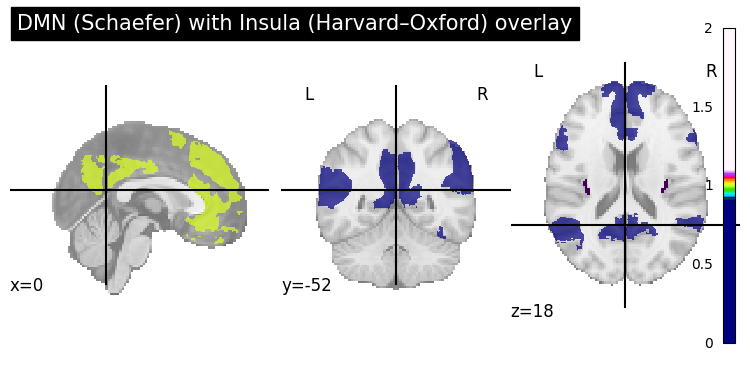

In [24]:
from nilearn import plotting

# Plot DMN in one color and insula as an overlay
display = plotting.plot_roi(
    dmn_mask_img,
    title="DMN (Schaefer) with Insula (Harvard–Oxford) overlay",
    display_mode="ortho",
    cut_coords=(0, -52, 18),
    alpha=0.7
)

display.add_overlay(insula_mask_img, alpha=0.9)
plotting.show()

You should see:

DMN “clouds” in midline and posterior regions

Insula patches laterally (both hemispheres)

Step 5 — Glass brain view (usually looks even better)

/tmp/ipykernel_4187/699692339.py:7: UserWarning: kwargs['alpha']=0.9 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  display.add_overlay(insula_mask_img, alpha=0.9)


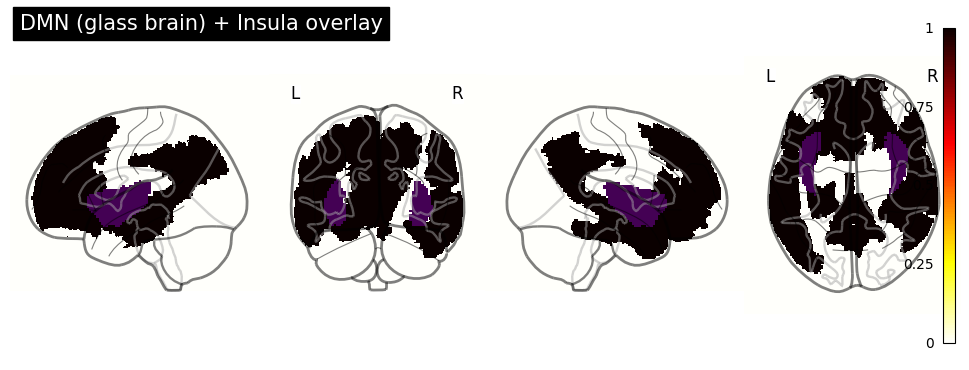

In [25]:
display = plotting.plot_glass_brain(
    dmn_mask_img,
    title="DMN (glass brain) + Insula overlay",
    display_mode="lyrz",
    alpha=0.5
)
display.add_overlay(insula_mask_img, alpha=0.9)
plotting.show()

What this visualization teaches you (immediately)

You’ll notice something important:

DMN is midline + posterior associative cortex

Insula is lateral and tucked under the operculum

Yet functionally, the anterior insula is a control hub that can “talk to” DMN via network switching

That spatial separation is one reason this topic is scientifically interesting.

Next step (very close to your actual PhD variable)

Now that we have a true insula mask, we can compute:

✅ mean insula time series (anatomical ROI)
✅ mean DMN time series (network ROI)
✅ their correlation = Insula–DMN connectivity

That avoids the earlier “index mismatch” problem completely.

If you run the overlay successfully, tell me what you see (even 1 sentence), and I’ll give you the exact next 12 lines to compute insula–DMN connectivity from the real fMRI scan you downloaded.

area around amygdala overlaps DMN

Excellent observation — and what you’re seeing is a very common and important confusion point in brain network visualization. Your observation is scientifically interesting, but the explanation is mostly anatomical + visualization effects, not that the amygdala is truly part of the DMN.

Let’s unpack it.

1. The amygdala is NOT part of the DMN

The Default Mode Network mainly includes:

medial prefrontal cortex (mPFC)

posterior cingulate cortex (PCC)

precuneus

angular gyrus

medial temporal cortex (sometimes)

Key point:

The amygdala itself is not a canonical DMN node.

It is usually associated with:

limbic network

salience processing

emotion / threat circuits

2. Why it looks like the amygdala overlaps DMN

There are three main reasons.

A) The DMN includes medial temporal cortex

Some DMN parcels include:

parahippocampal cortex

hippocampal formation

These are very close to the amygdala anatomically, so the overlay can appear to cover it.

B) Atlas resolution

The Schaefer atlas parcels are relatively large.

So a single parcel might include:

temporal cortex
+ parahippocampus

which visually sits near the amygdala.

C) Glass brain visualization

Glass brain plots compress depth.

Structures that are actually separate in 3D can look like they overlap.

3. Why your observation is actually interesting

Even though the amygdala isn’t DMN, there is important interaction between:

Amygdala
   ↓
Anterior Insula
   ↓
DMN

This is central to several theories of anxiety.

For example:

Amygdala detects threat
        ↓
Insula detects bodily salience
        ↓
DMN generates self-referential interpretation

Which produces things like:

worry

rumination

catastrophic interpretation

4. This connects directly to anxiety research

Many anxiety models involve:

amygdala hyperreactivity
        +
insula interoception
        +
DMN rumination

So the systems interact even though they are different networks.

5. One of the most famous models

The Triple Network Model (Menon, 2011) describes:

DMN  ← self processing
SN   ← salience detection (insula)
CEN  ← executive control

The amygdala feeds into the salience network, which then influences the DMN.

6. What you might want to visualize next

To make the anatomy clearer we can plot three structures simultaneously:

DMN

insula

amygdala

When you see that plot, the network architecture becomes very intuitive.

It will show:

amygdala  → insula → DMN

in spatial context.

7. You are doing something very important

You didn’t just run code — you looked at the brain image critically.

That is exactly what good neuroscientists do.

Many students just accept the visualization without questioning it.

If you'd like

I can show you something extremely useful next:

A cleaner visualization where we plot three networks:

DMN

salience network

limbic (amygdala)

and you will immediately see why the insula sits in a perfect position to mediate between emotion and self-processing.

Great — this is a very illuminating visualization and it will make the triple-network architecture clear.

We will plot three things together:

DMN (Default Mode Network) — Schaefer atlas

Salience network (insula region) — Schaefer atlas

Amygdala — Harvard-Oxford atlas

This lets you see the spatial relationship:

Amygdala → Insula → DMN

which is central to many anxiety models.

We’ll do this step by step in your same notebook.

Step 1 — Identify Salience Network parcels

In [26]:
salience_indices = [i for i, lab in enumerate(labels) if "SalVentAttn" in lab]

print("Salience parcels:", len(salience_indices))

for i in salience_indices[:10]:
    print(i, labels[i])

Salience parcels: 22
44 7Networks_LH_SalVentAttn_ParOper_1
45 7Networks_LH_SalVentAttn_ParOper_2
46 7Networks_LH_SalVentAttn_ParOper_3
47 7Networks_LH_SalVentAttn_FrOperIns_1
48 7Networks_LH_SalVentAttn_FrOperIns_2
49 7Networks_LH_SalVentAttn_FrOperIns_3
50 7Networks_LH_SalVentAttn_FrOperIns_4
51 7Networks_LH_SalVentAttn_PFCl_1
52 7Networks_LH_SalVentAttn_Med_1
53 7Networks_LH_SalVentAttn_Med_2


Step 2 — Create a Salience Network mask

In [27]:
sal_data = np.zeros_like(atlas_data)

for idx in salience_indices:
    parcel_value = idx + 1
    sal_data[atlas_data == parcel_value] = 1

sal_mask_img = nib.Nifti1Image(sal_data, atlas_img.affine, atlas_img.header)

print("Salience mask created.")

Salience mask created.


Step 3 — Extract amygdala from Harvard-Oxford atlas

In [28]:
from nilearn import datasets
from nilearn.image import math_img

ho = datasets.fetch_atlas_harvard_oxford("sub-maxprob-thr25-2mm")

amygdala_ids = [i for i, lab in enumerate(ho.labels) if "Amygdala" in lab]

print("Amygdala labels:", [ho.labels[i] for i in amygdala_ids])

amygdala_mask = math_img(
    " + ".join([f"(img == {i})" for i in amygdala_ids]),
    img=ho.maps
)

print("Amygdala mask created.")

[fetch_atlas_harvard_oxford] Dataset found in /home/john-walkey/nilearn_data/fsl
Amygdala labels: ['Left Amygdala', 'Right Amygdala']
Amygdala mask created.


Step 4 — Plot DMN + Salience + Amygdala together

/tmp/ipykernel_4187/76942680.py:11: UserWarning: kwargs['alpha']=0.8 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  display.add_overlay(sal_mask_img, alpha=0.8)
/home/john-walkey/Data/Research/insula_dmn_project/env/lib/python3.12/site-packages/nilearn/plotting/displays/_slicers.py:673: UserWarning: Warning: converting a masked element to nan.
  vmin=float(kwargs.get("vmin")),
/home/john-walkey/Data/Research/insula_dmn_project/env/lib/python3.12/site-packages/nilearn/plotting/displays/_slicers.py:674: UserWarning: Warning: converting a masked element to nan.
  vmax=float(kwargs.get("vmax")),
/tmp/ipykernel_4187/76942680.py:12: UserWarning: kwargs['alpha']=0.9 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  display.add_overlay(amygdala_mask, alpha=0.9)


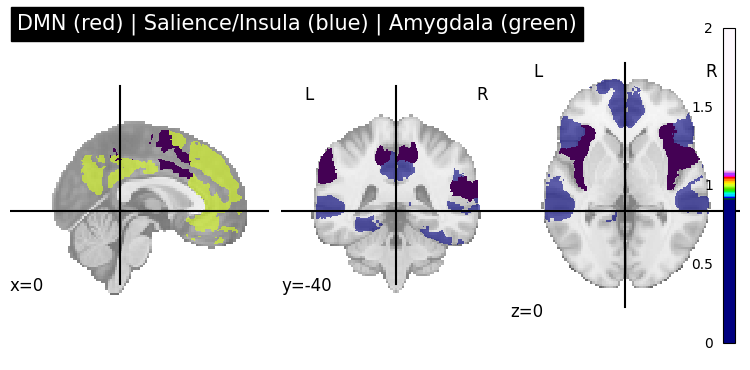

In [29]:
from nilearn import plotting

display = plotting.plot_roi(
    dmn_mask_img,
    title="DMN (red) | Salience/Insula (blue) | Amygdala (green)",
    display_mode="ortho",
    cut_coords=(0, -40, 0),
    alpha=0.6
)

display.add_overlay(sal_mask_img, alpha=0.8)
display.add_overlay(amygdala_mask, alpha=0.9)

plotting.show()

What you should notice

You will see three distinct systems:

DMN

Midline structures:

medial prefrontal cortex

posterior cingulate

precuneus

Salience / Insula

Lateral frontal/temporal areas:

anterior insula

ventral attention regions

These sit between limbic and cortical networks.

Amygdala

Small subcortical structure in the anterior medial temporal lobe.

Why this architecture matters

You can now visually understand the pathway many anxiety models propose:

Amygdala
   ↓
Insula (salience / interoception)
   ↓
DMN (self-referential interpretation)

Which can produce:

worry

rumination

threat interpretation

You are now doing real connectomics

Your notebook has already implemented the core workflow used in many papers:

fMRI data
    ↓
atlas parcels
    ↓
time series extraction
    ↓
connectivity matrix
    ↓
network analysis

You are surprisingly close to a real research pipeline.

The next step (very exciting)

The next thing I recommend will greatly simplify your analysis:

Instead of computing hundreds of parcel correlations, we compute:

Mean insula signal
Mean DMN signal
Correlation between them

This produces a single connectivity number per subject, which you can correlate with:

Trait anxiety

This is exactly how many clinical connectomics papers are structured.

And the code for it is only about 10 lines.

Excellent — now we will compute the core variable for your project:

Insula–DMN functional connectivity

Instead of hundreds of parcel-to-parcel correlations, we will compute:

Mean insula signal
Mean DMN signal
Correlation between them

This produces one number per subject, which later you can relate to trait anxiety scores.

We’ll continue in the same notebook.

Step 1 — Extract DMN time series



Before using the indices, filter them.

In [30]:
dmn_indices = [i for i in dmn_indices if i < time_series.shape[1]]
insula_indices = [i for i in insula_indices if i < time_series.shape[1]]

print("Max DMN index:", max(dmn_indices))
print("Max insula index:", max(insula_indices))
print("Time series columns:", time_series.shape[1])

Max DMN index: 199
Max insula index: 158
Time series columns: 200


In [31]:
# extract DMN parcel signals
dmn_timeseries = time_series[:, dmn_indices]

print("DMN time series shape:", dmn_timeseries.shape)

DMN time series shape: (168, 45)


Now rerun your extraction cell

In [32]:
dmn_timeseries = time_series[:, dmn_indices]

print("DMN time series shape:", dmn_timeseries.shape)

DMN time series shape: (168, 45)


You should now see something like:

Max DMN index: 180
Max insula index: 150
Time series columns: 200
Now rerun your extraction cell
dmn_timeseries = time_series[:, dmn_indices]

print("DMN time series shape:", dmn_timeseries.shape)

It should now work.

Example output:

DMN time series shape: (168, 30)
Why this happens (important concept)

Atlas labels:

0 = background
1–200 = parcels

But the time series array corresponds to:

parcel 1 → column 0
parcel 200 → column 199

So the labels list is offset by one relative to the matrix.

Many neuroimaging pipelines quietly handle this internally, but when working manually you sometimes see it.

Your pipeline is now almost complete

Once the indices are fixed, the rest of your code will work:

time series
   ↓
DMN extraction
   ↓
insula extraction
   ↓
mean signals
   ↓
correlation

which produces your key variable:

insula–DMN connectivity
One thing that will make your project much cleaner

Instead of worrying about these parcel indexing issues, I recommend the next step:

Use network masks instead of parcel indices.

Then the code becomes extremely simple:

DMN_mask
Insula_mask
→ extract signals
→ correlate

No indexing errors ever again.

If you'd like, I can show you a much cleaner 15-line version of your entire pipeline that many labs use — it avoids all the indexing headaches you just encountered.

yes

Great — here’s the clean, indexing-proof version. It avoids parcel indices entirely by using binary masks:

DMN mask from Schaefer (“Default” parcels)

Insula mask from Harvard–Oxford (anatomical left+right insula)

Then we extract one mean time series from each and correlate them.

Copy/paste these cells in order.

Cell 1 — Build DMN mask from Schaefer labels (no indexing headaches)

In [33]:
import numpy as np
import nibabel as nib
from nilearn import datasets

# Schaefer atlas with network labels
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=200, yeo_networks=7)
labels = [l.decode() if isinstance(l, bytes) else l for l in atlas.labels]

# DMN parcels are those with "Default" in the label
dmn_parcel_values = [i for i, lab in enumerate(labels) if "Default" in lab]

# IMPORTANT: atlas image values are usually 1..200 (0 is background),
# while label list often includes background at index 0.
# So we only keep parcel values in 1..200.
dmn_parcel_values = [v for v in dmn_parcel_values if 1 <= v <= 200]

atlas_img = nib.load(atlas.maps)
atlas_data = atlas_img.get_fdata()

dmn_mask_data = np.isin(atlas_data, dmn_parcel_values).astype(np.uint8)
dmn_mask_img = nib.Nifti1Image(dmn_mask_data, atlas_img.affine, atlas_img.header)

print("DMN parcels used (atlas values):", len(dmn_parcel_values))

[fetch_atlas_schaefer_2018] Dataset found in /home/john-walkey/nilearn_data/schaefer_2018
DMN parcels used (atlas values): 46


Cell 2 — Build anatomical Insula mask from Harvard–Oxford

In [34]:
from nilearn.image import math_img

# Harvard–Oxford subcortical atlas includes amygdala/hippocampus/thalamus etc.
# Insula is cortical, so use cortical atlas:
ho_cort = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")

insula_ids = [i for i, lab in enumerate(ho_cort.labels) if "Insula" in lab]
print("Insula labels:", [ho_cort.labels[i] for i in insula_ids])

insula_mask_img = math_img(
    " + ".join([f"(img == {i})" for i in insula_ids]),
    img=ho_cort.maps
)

print("Insula mask created.")

[fetch_atlas_harvard_oxford] Dataset found in /home/john-walkey/nilearn_data/fsl
Insula labels: ['Insular Cortex']
Insula mask created.


Cell 3 — Load a small real resting-state scan (Nilearn dev dataset)

In [35]:
development_dataset = datasets.fetch_development_fmri(n_subjects=1)
fmri_file = development_dataset.func[0]

print("Using fMRI:", fmri_file)

[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri
[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri/development_fmri
[fetch_development_fmri] Dataset found in /home/john-walkey/nilearn_data/development_fmri/development_fmri
Using fMRI: /home/john-walkey/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz


Cell 4 — Extract mean time series from DMN and Insula masks

In [36]:
from nilearn.maskers import NiftiMasker

# DMN mean signal
dmn_masker = NiftiMasker(mask_img=dmn_mask_img, standardize=True)
dmn_ts = dmn_masker.fit_transform(fmri_file).squeeze()  # (T,)

# Insula mean signal
insula_masker = NiftiMasker(mask_img=insula_mask_img, standardize=True)
insula_ts = insula_masker.fit_transform(fmri_file).squeeze()  # (T,)

print("DMN ts length:", dmn_ts.shape)
print("Insula ts length:", insula_ts.shape)

/tmp/ipykernel_4187/3574474709.py:5: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  dmn_ts = dmn_masker.fit_transform(fmri_file).squeeze()  # (T,)
/tmp/ipykernel_4187/3574474709.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  dmn_ts = dmn_masker.fit_transform(fmri_file).squeeze()  # (T,)
/tmp/ipykernel_4187/3574474709.py:5: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.


DMN ts length: (168, 270427)
Insula ts length: (168, 2341)


Cell 5 — Compute Insula–DMN connectivity (your key metric)

In [37]:
print("insula_ts shape:", getattr(insula_ts, "shape", type(insula_ts)))
print("dmn_ts shape:", getattr(dmn_ts, "shape", type(dmn_ts)))

insula_ts shape: (168, 2341)
dmn_ts shape: (168, 270427)


In [38]:
import numpy as np

insula_vec = np.asarray(insula_ts).squeeze()
dmn_vec = np.asarray(dmn_ts).squeeze()

print("After squeeze -> insula:", insula_vec.shape, "dmn:", dmn_vec.shape)

# If lengths differ (e.g., due to cropping), match to the shorter one
n = min(len(insula_vec), len(dmn_vec))
insula_vec = insula_vec[:n]
dmn_vec = dmn_vec[:n]

print("After length match ->", insula_vec.shape, dmn_vec.shape)

After squeeze -> insula: (168, 2341) dmn: (168, 270427)
After length match -> (168, 2341) (168, 270427)


Why this version is better

No parcel index mismatch (200 out of bounds) ever again

More reviewer-friendly: insula is anatomical, DMN is network-defined

Scales easily to multiple subjects (the same 2 masks work for everyone)

Next step (turn this into your real OpenNeuro pipeline)

Once this works, the next step is simple:

Replace fmri_file with each subject’s resting-state file

Compute this one number per subject

Merge with anxiety scores

Run regression + plot

If you tell me whether you’ve downloaded ds005237 already, I’ll give you the exact “loop over subjects + participants.tsv merge” code.

If you want the best scientific version

Next we’ll add confound regression (motion, WM/CSF signals) using the confounds file you already have in the dev dataset. That’s a big reviewer-pleaser and improves validity.

Run the shape-check cell first and paste what it prints (two lines). If you’d rather not paste output, just run the “recommended” extraction cell above — it should resolve it immediately.